# Model Explainability

This notebook investigates how the saved obesity classification
model uses its input features.

The workflow:
- Loads the final pipeline, metadata, and reserved test data.
- Examines the classifier's built-in feature importance.
- Uses SHAP to explain predictions across a sample of records.
- Explains one individual prediction.
- Saves feature importance and local explanation tables.

The saved model is used without retraining. Explanations describe
model behaviour; they do not establish causal relationships.

## Import Explainability Tools

Joblib loads the saved pipeline, while JSON reads its metadata.
NumPy and pandas support numerical operations and tables.

Matplotlib displays feature importance and SHAP plots.
SHAP estimates feature contributions to model predictions.
Path supports locating project files.

In [1]:
from pathlib import Path
import json

import shap
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

c:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Locate Project Directories

Starting from the current working directory, the code searches
upward for a directory containing the `models` folder.

It then defines paths for saved models, processed data, and
generated reports. If the project root cannot be found,
execution stops with an error.

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "models").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "Could not locate project root"
        )

    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports" / "generated"
DATA = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Models:", MODELS)
print("Data:", DATA)
print("Reports:", REPORTS)

Project root: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM
Models: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\models
Data: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\data\processed
Reports: C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated


## Load the Final Pipeline and Metadata

The fitted pipeline is loaded from
`models/obesity_risk_pipeline.joblib`.

Its metadata is loaded from `models/model_metadata.json`.
The selected candidate and selection metric are displayed
to confirm which model is being explained.

No model training occurs in this notebook.

In [3]:
model_path = MODELS / "obesity_risk_pipeline.joblib"
metadata_path = MODELS / "model_metadata.json"

final_model = joblib.load(model_path)

with open(metadata_path, "r") as file:
    metadata = json.load(file)

print("Model loaded successfully")
print("Metadata loaded successfully")

print("\nSelected Model:")
print(metadata["selected_candidate"])

print("\nSelection Metric:")
print(metadata["selection_metric"])

Model loaded successfully
Metadata loaded successfully

Selected Model:
Gradient Boosting - Tuned

Selection Metric:
Macro F1


## Load the Reserved Test Data

The test features and labels saved in Notebook 05 are loaded.

These records support prediction and explanation of the final
model. Their dimensions are displayed to check the loaded data.

Feature rows and target labels must retain their original alignment.

In [4]:
X_test = pd.read_csv(
    DATA / "X_test.csv"
)

y_test = pd.read_csv(
    DATA / "y_test.csv"
).squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (3114, 16)
y_test shape: (3114,)


## Generate Predictions and Probabilities

The complete fitted pipeline predicts the test records, applying
its saved preprocessing before classification.

Class probabilities are also generated when supported.
Probability columns follow the fitted classifier's class order.

These are model probability estimates and have not been shown
to be calibrated measures of clinical risk.

In [5]:
# Generate predictions using the final trained pipeline
test_predictions = final_model.predict(X_test)

# Generate prediction probabilities if supported
if hasattr(final_model, "predict_proba"):
    test_probabilities = final_model.predict_proba(X_test)
else:
    test_probabilities = None

print("Predictions generated successfully")
print("Number of predictions:", len(test_predictions))

if test_probabilities is not None:
    print("Probability predictions available:", test_probabilities.shape)

Predictions generated successfully
Number of predictions: 3114
Probability predictions available: (3114, 7)


## Retrieve Transformed Feature Names

The fitted preprocessor provides the feature names passed
to the classifier.

The original 16 inputs produce 25 transformed features because
categorical encoding expands some inputs into multiple columns.

These names are used to label importance scores and SHAP values.

In [6]:
preprocessor = final_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

print("\nFirst 10 feature names:")
print(feature_names[:10])

Number of transformed features: 25

First 10 feature names:
['numerical__Age' 'numerical__Height' 'numerical__Weight'
 'numerical__FCVC' 'numerical__NCP' 'numerical__CH2O' 'numerical__FAF'
 'numerical__TUE' 'ordinal__CAEC' 'ordinal__CALC']


## Calculate Built-In Feature Importance

The Gradient Boosting classifier provides importance scores
based on the impurity reductions achieved by its tree splits.

Scores are matched to transformed feature names and sorted
from highest to lowest. The top 15 are displayed.

These scores describe overall feature use but do not show
whether a feature increases or decreases a particular prediction.
They can also favour features with many possible split points.

In [7]:
classifier = final_model.named_steps["classifier"]

feature_importance = classifier.feature_importances_

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": feature_importance
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    importance_df.head(15)
)

,Feature,Importance
0,numerical__Weight,0.580780
1,numerical__FCVC,0.100567
2,numerical__Height,0.076616
3,nominal__Gender_Male,0.055070
4,nominal__Gender_Female,0.051784
5,numerical__Age,0.039661
6,numerical__TUE,0.025355
7,numerical__CH2O,0.015359
8,numerical__NCP,0.014888
9,ordinal__CALC,0.013725


## Plot the Most Important Features

A horizontal bar chart displays the 15 highest-ranked transformed
features according to the classifier's built-in importance scores.

Larger bars indicate greater importance under this measure.
Encoded categories appear separately rather than being grouped
under their original input feature.

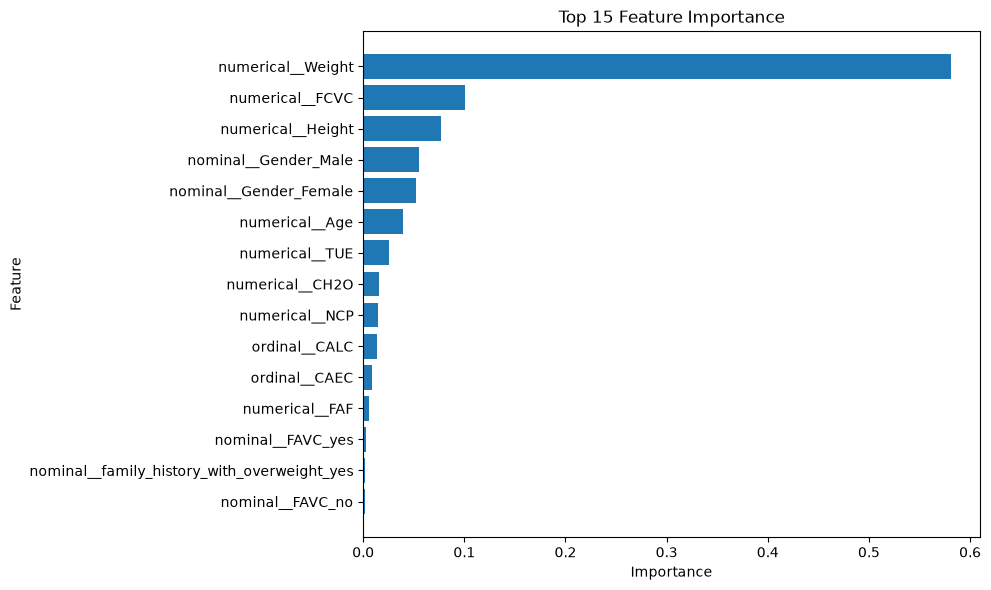

In [8]:
# Top 15 important features
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")

plt.tight_layout()
plt.show()

## Generate SHAP Explanations

The fitted preprocessor transforms test records into the feature
space used by the classifier. It is not fitted again.

The original training partition is recreated using the same
stratified split and random seed as Notebook 05. Fifty training
records are sampled and transformed to provide SHAP's background
reference.

PermutationExplainer estimates how transformed features contribute
to each class probability relative to that reference.

The first 100 test records are explained to limit computation.
They are a subset, rather than a representative random sample
of the entire test set.

The resulting values have dimensions:
records × transformed features × classes.

In [9]:
# Extract pipeline components
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["classifier"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix if required
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

print("Transformed feature shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

# Training-data background samples for SHAP
from sklearn.model_selection import train_test_split

raw_data = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "obesity.csv"
)

X_raw = raw_data[metadata["predictive_features"]]
y_raw = raw_data["NObeyesdad"]

X_background_train, _, _, _ = train_test_split(
    X_raw,
    y_raw,
    test_size=0.30,
    random_state=42,
    stratify=y_raw,
)

background_sample = X_background_train.sample(
    n=50,
    random_state=42,
)

X_shap_background = preprocessor.transform(
    background_sample
)

# Prediction function for classifier only
def shap_predict_proba(data):
    return classifier.predict_proba(data)

# Create SHAP explainer
explainer = shap.PermutationExplainer(
    shap_predict_proba,
    X_shap_background,
    feature_names=list(feature_names),
    seed=42
)

# Generate SHAP values
X_shap_sample = X_test_transformed[:100]

shap_values = explainer(
    X_shap_sample
)

print("\nSHAP explanation generated successfully")
print("SHAP values shape:", shap_values.values.shape)

Transformed feature shape: (3114, 25)
Number of feature names: 25


PermutationExplainer explainer: 101it [00:12,  3.33it/s]                         


SHAP explanation generated successfully
SHAP values shape: (100, 25, 7)


## Examine SHAP Contributions for Obesity Type III

The class index is obtained from the fitted classifier's
`classes_` attribute, matching the probability output order.

The summary plot displays contributions to the Obesity Type III
probability across the 100 explained records.

- Positive SHAP values increase this class's probability
  relative to the background reference.
- Negative values decrease it.
- Features are ordered by mean absolute contribution.
- Colour represents the transformed feature value.

This plot explains one class within the sampled records.
It does not summarise every class or the entire dataset.

C:\Users\User\AppData\Local\Temp\ipykernel_18832\104065727.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Explaining class:
Obesity_Type_III

Class index:
4

Selected class SHAP shape:
(100, 25)

Feature count:
25


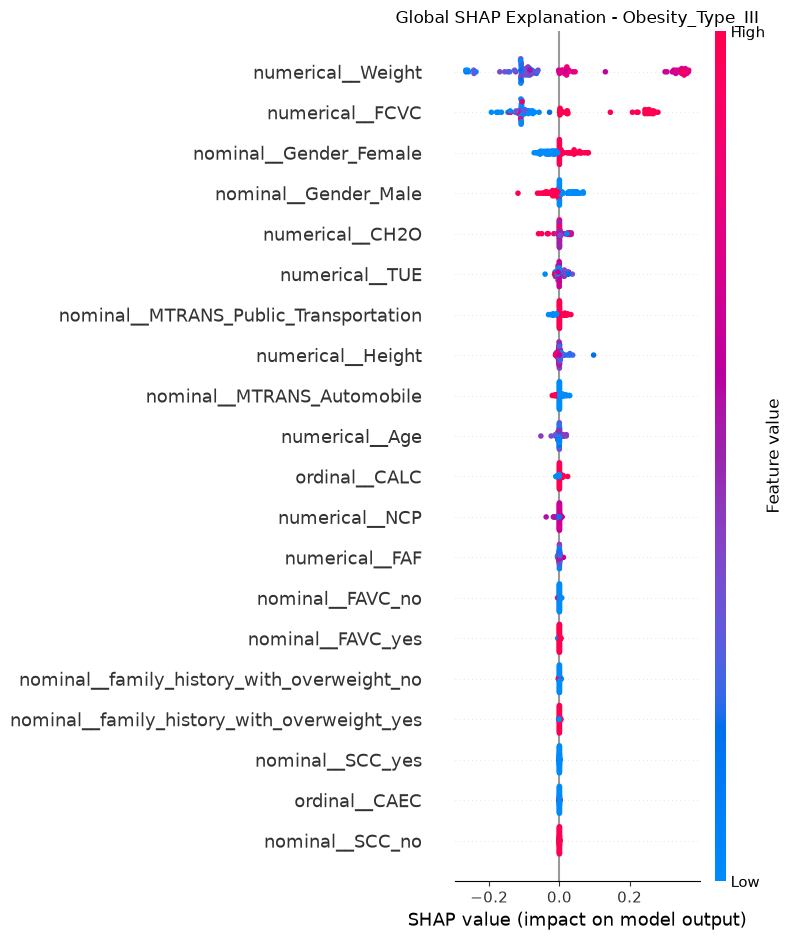

In [10]:
# Select class for explanation
explain_class = "Obesity_Type_III"

# Get class index from the fitted classifier
class_index = list(classifier.classes_).index(
    explain_class
)

print("Explaining class:")
print(explain_class)

print("\nClass index:")
print(class_index)

# Select SHAP values for selected class
selected_class_shap = (
    shap_values.values[:, :, class_index]
)

print("\nSelected class SHAP shape:")
print(selected_class_shap.shape)

print("\nFeature count:")
print(len(feature_names))

# Generate global SHAP summary plot
plt.figure(figsize=(12, 8))

shap.summary_plot(
    selected_class_shap,
    X_shap_sample,
    feature_names=feature_names,
    show=False
)

plt.title(
    f"Global SHAP Explanation - {explain_class}"
)

plt.tight_layout()

plt.show()

## Explain One Individual Prediction

The first explained test record is selected. Its predicted class
and class probabilities are displayed using the classifier's
class order.

SHAP values are extracted for this record's predicted class.
Features are ranked by absolute contribution, and the ten
largest contributions are displayed.

The signed SHAP value shows contribution direction.
Absolute impact shows contribution magnitude.

This explanation applies to this particular prediction relative
to the chosen background reference.

In [11]:
# Select one test sample
sample_index = 0

sample = X_shap_sample[sample_index]

# Generate prediction
prediction = classifier.predict(
    sample.reshape(1, -1)
)[0]

# Generate probabilities
probability = classifier.predict_proba(
    sample.reshape(1, -1)
)[0]

print("Sample index:", sample_index)

print("Predicted class:", prediction)

print("\nClass probabilities:")

# Use classifier classes to avoid mismatch
model_classes = [
    str(class_name)
    for class_name in classifier.classes_
]

for class_name, prob in zip(
    model_classes,
    probability
):
    print(
        f"{class_name}: {prob:.4f}"
    )

# Get SHAP values for selected sample
sample_shap = shap_values.values[sample_index]

# Find predicted class index
class_index = model_classes.index(
    str(prediction)
)

# Select SHAP values for predicted class
predicted_class_shap = (
    sample_shap[:, class_index]
)

print("\nSHAP values shape:")
print(predicted_class_shap.shape)

# Create explanation dataframe
local_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "SHAP Value": predicted_class_shap
    }
)

# Calculate contribution magnitude
local_df["Absolute Impact"] = (
    local_df["SHAP Value"]
    .abs()
)

# Sort by impact
local_df = local_df.sort_values(
    by="Absolute Impact",
    ascending=False
).reset_index(drop=True)

print("\nTop contributing features:")

display(
    local_df.head(10)
)

Sample index: 0
Predicted class: Obesity_Type_III

Class probabilities:
Insufficient_Weight: 0.0000
Normal_Weight: 0.0000
Obesity_Type_I: 0.0007
Obesity_Type_II: 0.0000
Obesity_Type_III: 0.9992
Overweight_Level_I: 0.0000
Overweight_Level_II: 0.0000

SHAP values shape:
(25,)

Top contributing features:


,Feature,SHAP Value,Absolute Impact
0,numerical__Weight,0.325586,0.325586
1,numerical__FCVC,0.253273,0.253273
2,nominal__Gender_Female,0.035141,0.035141
3,numerical__Height,0.029684,0.029684
4,nominal__Gender_Male,0.023466,0.023466
5,numerical__TUE,0.023445,0.023445
6,nominal__MTRANS_Public_Transportation,0.023410,0.023410
7,numerical__CH2O,0.021700,0.021700
8,nominal__MTRANS_Automobile,0.017793,0.017793
9,numerical__Age,0.010155,0.010155


## Save Explainability Results

Two tables are exported:
- `feature_importance.csv`: built-in importance scores for
  all transformed features.
- `local_shap_explanation.csv`: feature contributions for
  the selected record's predicted class.

The reports directory is created if needed, and file existence
is displayed after saving.

The plots and full set of SHAP values are not exported by this cell.

In [12]:
# Create reports directory if not available
REPORTS.mkdir(
    parents=True,
    exist_ok=True
)

# Save feature importance results
importance_path = REPORTS / "feature_importance.csv"

importance_df.to_csv(
    importance_path,
    index=False
)

# Save local SHAP explanation
shap_local_path = REPORTS / "local_shap_explanation.csv"

local_df.to_csv(
    shap_local_path,
    index=False
)

print("Saved files:")
print(importance_path)
print(shap_local_path)

# Verify files exist
print("\nFile verification:")

print(
    "Feature importance exists:",
    importance_path.exists()
)

print(
    "Local SHAP explanation exists:",
    shap_local_path.exists()
)

Saved files:
C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\feature_importance.csv
C:\Users\User\OneDrive\Desktop\Mathuran-Repo-FDM\reports\generated\local_shap_explanation.csv

File verification:
Feature importance exists: True
Local SHAP explanation exists: True


## Check Explainability Output Files

The final check confirms whether both expected CSV files exist
and reports any missing outputs.

File existence confirms that the reports are available.
It does not independently validate their contents or establish
the correctness of the explanations.

In [13]:
feature_file = REPORTS / "feature_importance.csv"
shap_file = REPORTS / "local_shap_explanation.csv"

print("Feature importance file exists:",
      feature_file.exists())

print("Local SHAP explanation file exists:",
      shap_file.exists())

if feature_file.exists() and shap_file.exists():
    print("\nExplainability workflow completed successfully")
else:
    print("\nSome explainability outputs are missing")

Feature importance file exists: True
Local SHAP explanation file exists: True

Explainability workflow completed successfully
